# Qwen3Guard-Gen

In [1]:
from math import comb
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces
from streamguard_bench.metrics import (
    compute_prompt_metrics,
    compute_response_policy_metrics,
    compute_streaming_metrics,
)
from streamguard_bench.pipeline import load_config, run_or_load, saved_run_exists

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

## Прогон

In [2]:
PROFILE = "full"
FORCE_RERUN = False

config = load_config("configs/qwen3guard_gen.yaml", root=project_root)
experiment = config["experiment"]
MODES = experiment["modes"]
POLICY = "conservative"

dataset = pd.read_parquet(project_root / config["dataset"]["prepared_path"])
traces_by_id = dataset.set_index("trace_id")

if saved_run_exists(config, profile=PROFILE, root=project_root) and not FORCE_RERUN:
    print(f"Найден сохранённый прогон профиля {PROFILE}: модель не запускается.")
run = run_or_load(config, profile=PROFILE, root=project_root, force=FORCE_RERUN)

print(f"Модель: {config['model']['repository']} @ {config['model']['revision'][:8]}")
print(f"Режимы буфера: {', '.join(MODES)}")
print(f"Трасс: {len(run.selected_trace_ids)}; ошибок обработки: {len(run.errors)}")

Найден сохранённый прогон профиля full: модель не запускается.
Модель: Qwen/Qwen3Guard-Gen-0.6B @ fada3b2f
Режимы буфера: chunk_8, chunk_16, chunk_32, sentence, full_buffered
Трасс: 210; ошибок обработки: 0


## Понимает ли модель сам запрос?

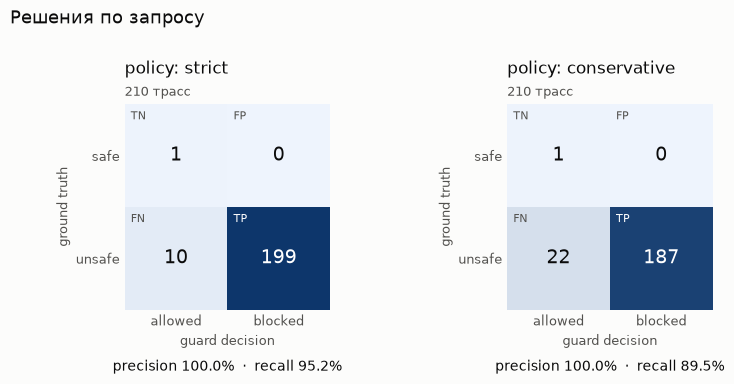

In [3]:
prompt_metrics = compute_prompt_metrics(run.prompt_decisions).round(3)
figure = plots.plot_confusion_matrices(prompt_metrics, title="Решения по запросу")

Из 209 опасных запросов `strict` находит 199, `conservative` 187. Безопасный запрос в наборе один, поэтому нулевая доля ложных срабатываний на запросах ничего не говорит о модели.

## Насколько хорошо блокируются ответы?

,mode,policy,tp,fp,tn,fn,false_positive_rate,false_negative_rate
0,chunk_8,conservative,116,25,63,6,0.284,0.049
1,chunk_8,strict,119,32,56,3,0.364,0.025
2,chunk_16,conservative,116,21,67,6,0.239,0.049
3,chunk_16,strict,119,23,65,3,0.261,0.025
4,chunk_32,conservative,116,15,73,6,0.170,0.049
5,chunk_32,strict,119,18,70,3,0.205,0.025
6,sentence,conservative,116,20,68,6,0.227,0.049
7,sentence,strict,118,20,68,4,0.227,0.033
8,full_buffered,conservative,114,1,87,8,0.011,0.066
9,full_buffered,strict,116,2,86,6,0.023,0.049


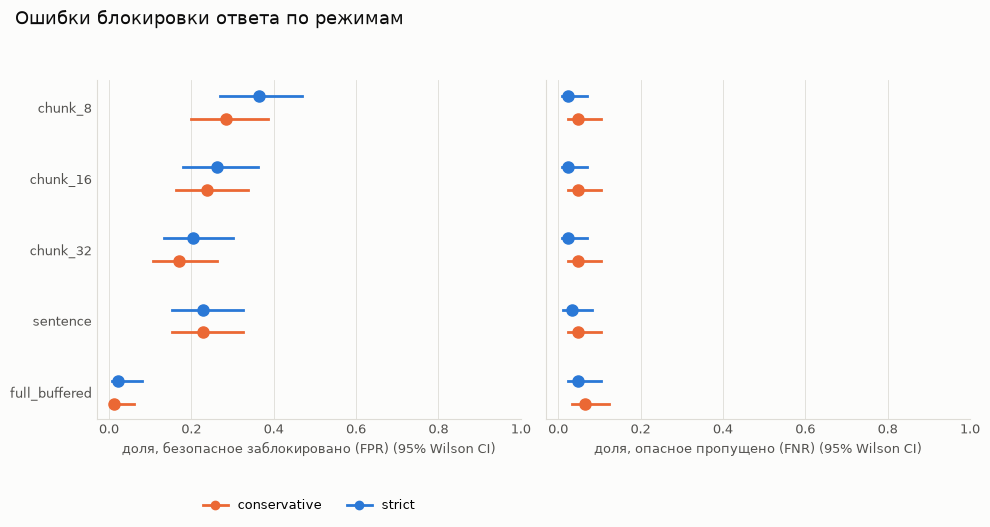

In [4]:
response_metrics = pd.concat(
    [
        compute_response_policy_metrics(
            run.intervention_results[run.intervention_results["mode"] == mode]
        ).assign(mode=mode)
        for mode in MODES
    ],
    ignore_index=True,
)
columns = ["mode", "policy", "tp", "fp", "tn", "fn", "false_positive_rate", "false_negative_rate"]
display(response_metrics[columns].round(3))
figure = plots.plot_mode_error_rates(response_metrics, title="Ошибки блокировки ответа по режимам")

Из 88 безопасных ответов полная буферизация блокирует один (`conservative`) или два (`strict`). Режимы, которые проверяют префиксы, блокируют от 15 до 25 при `conservative` и от 18 до 32 при `strict`: интервалы не пересекаются с интервалом `full_buffered`. Чем чаще проверка, тем больше ложных блокировок: от 17% в `chunk_32` до 28% в `chunk_8` (`conservative`). Интервалы chunk-режимов между собой пересекаются, так что порядок между ними строго утверждать нельзя.

Пропусков опасных ответов немного: 6 из 122 в режимах с проверкой по ходу ответа и 8 при полной буферизации (`conservative`), 3–4 и 6 при `strict`. Эта разница на 122 ответах находится в пределах интервалов. Цена полной буферизации в том, что пользователь ждёт весь ответ, а метрики это не показывают.

### Когда модель срабатывает относительно начала вреда

Слева срабатывания до размеченного начала опасного фрагмента, в центре после него, справа ответы, на которых блокировки не было. Показан самый частый режим проверки, `chunk_8`.

вредных ответов: 122; до onset: 41; после: 75; без сигнала: 6
медианная задержка после onset: 7 токенов


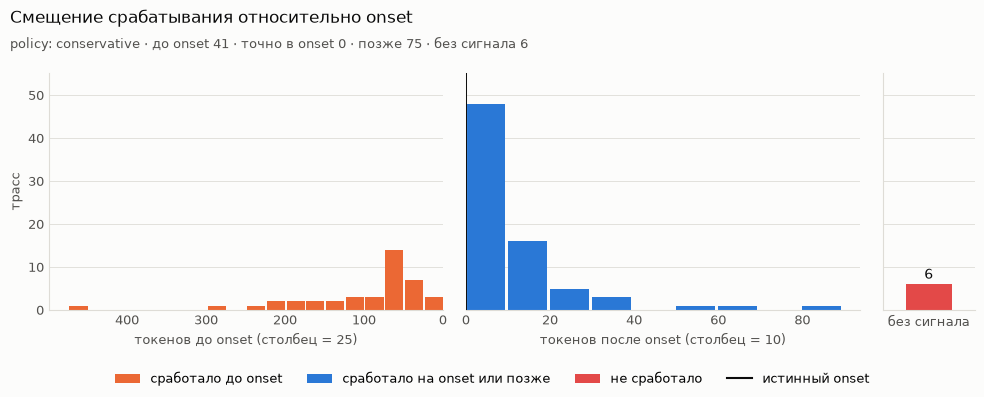

In [5]:
finest = run.intervention_results[run.intervention_results["mode"] == "chunk_8"]
figure = plots.plot_signal_offset(finest, policy=POLICY)

unsafe = finest[(finest["policy"] == POLICY) & (finest["response_ground_truth"] == "unsafe")]
offsets = unsafe["signal_offset_tokens"]
print(
    f"вредных ответов: {len(unsafe)}; до onset: {(offsets < 0).sum()}; после: "
    f"{(offsets >= 0).sum()}; без сигнала: {offsets.isna().sum()}"
)
print(f"медианная задержка после onset: {unsafe['detection_delay_tokens'].median():.0f} токенов")

Задержка определяется шагом проверки: медиана около 7 токенов для `chunk_8`, 15 для `chunk_16`, 31 для `chunk_32`, 28 для `sentence` и около 95 для `full_buffered`. Модель находит вред на первой проверке после начала вредного фрагмента, а точнее раньше проверок нет.

В 20–34% вредных ответов (`conservative`) модель срабатывает раньше размеченной границы. Одно из возможных объяснений: она видит опасный запрос целиком и может реагировать на него, а не на текст ответа. Этот эксперимент это не проверяет.

## Сколько вредного текста уходит пользователю

,mode,policy,leakage_mean,leakage_median,leakage_p90,zero_leakage_rate,post_signal_buffer_delay_mean,safe_withheld_tokens_mean
0,chunk_16,conservative,7.59,0.0,17.9,0.68,0.0,78.39
1,chunk_16,strict,5.20,0.0,14.9,0.74,0.0,86.68
2,chunk_32,conservative,6.59,0.0,19.8,0.78,0.0,58.61
3,chunk_32,strict,4.52,0.0,14.9,0.81,0.0,69.34
4,chunk_8,conservative,6.98,0.0,16.8,0.72,0.0,90.78
5,chunk_8,strict,4.54,0.0,13.7,0.78,0.0,107.57
6,full_buffered,conservative,4.69,0.0,0.0,0.93,0.0,0.69
7,full_buffered,strict,4.18,0.0,0.0,0.95,0.0,4.56
8,sentence,conservative,5.19,0.0,15.5,0.85,0.0,74.65
9,sentence,strict,4.07,0.0,2.0,0.86,0.0,74.65


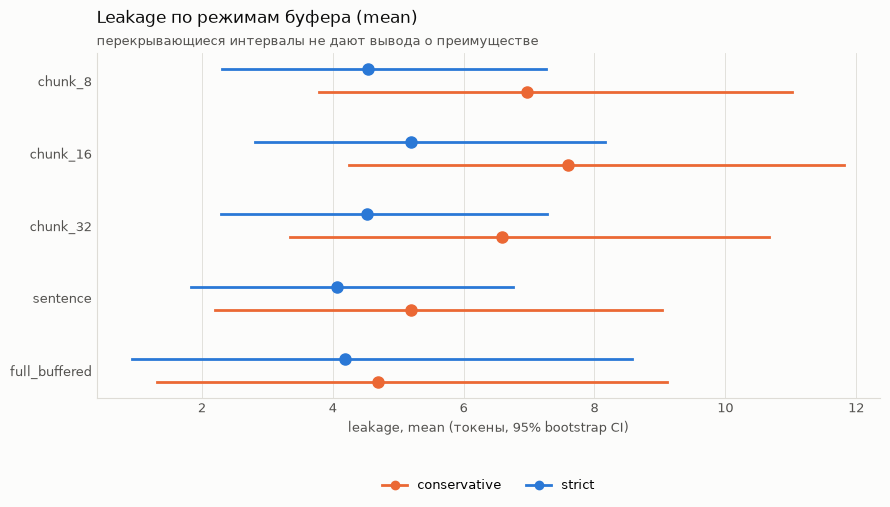

In [6]:
streaming_metrics = compute_streaming_metrics(run.intervention_results)
streaming_columns = [
    "mode",
    "policy",
    "leakage_mean",
    "leakage_median",
    "leakage_p90",
    "zero_leakage_rate",
    "post_signal_buffer_delay_mean",
    "safe_withheld_tokens_mean",
]
display(streaming_metrics[streaming_columns].round(2))
figure = plots.plot_leakage_intervals(streaming_metrics, statistic="mean")

Средняя утечка составляет 4,7–7,6 токена при `conservative`, у 68–93% вредных ответов утечки нет совсем, медиана во всех режимах равна нулю. Различия средней утечки между режимами лежат внутри доверительных интервалов, так что преимущество одного режима здесь не доказано. Остаток утечки дают пропущенные ответы, которые уходят пользователю целиком.

Цена частых проверок видна в другом столбце: среднее число токенов безопасного ответа, удержанных буфером, падает с 91 в `chunk_8` до менее одного токена при полной буферизации. Частые проверки чаще останавливают безопасные ответы.

## Откуда берутся ложные блокировки

Режимы с проверкой по ходу ответа блокируют безопасные ответы чаще, чем полная буферизация. Посмотрим, где именно в ответе это происходит.

In [7]:
safe = run.intervention_results[
    (run.intervention_results["policy"] == POLICY)
    & (run.intervention_results["response_ground_truth"] == "safe")
]
blocked = safe[safe["blocked"]]
table = (
    blocked.groupby("mode")["intervention_token"]
    .agg(
        ложных_блокировок="count",
        медианный_токен_блокировки="median",
        до_8_токена=lambda tokens: int((tokens <= 8).sum()),
        до_32_токена=lambda tokens: int((tokens <= 32).sum()),
    )
    .reindex(MODES)
)
display(table)

,ложных_блокировок,медианный_токен_блокировки,до_8_токена,до_32_токена
mode,,,,
chunk_8,25,8.0,20,23
chunk_16,21,16.0,0,19
chunk_32,15,32.0,0,13
sentence,20,2.0,16,18
full_buffered,1,61.0,0,0


В режиме `chunk_8` 20 из 25 безопасных ответов, заблокированных при `conservative`, остановлены на 8-м токене, то есть на первой же проверке. В `chunk_16` и `chunk_32` медиана токена блокировки равна 16 и 32. Медианная длина таких ответов около 300 токенов, блокировка приходится на первые несколько процентов. Из 25 ответов, заблокированных в `chunk_8`, полная буферизация блокирует только один: по началу они выглядят опасными, а на готовом ответе модель их пропускает.

Посмотрим, не связано ли это с форматом начала ответа: безопасные ответы, которые начинаются с нумерованного списка («1.»), блокируются чаще.

In [8]:
chunk8 = safe[safe["mode"] == "chunk_8"].copy()
chunk8["список"] = chunk8["trace_id"].map(
    lambda trace_id: traces_by_id.loc[trace_id, "response"].lstrip().startswith("1.")
)
by_start = chunk8.groupby("список")["blocked"].agg(["sum", "count", "mean"])
display(by_start.rename(columns={"sum": "заблокировано", "count": "ответов", "mean": "доля"}).round(3))


def fisher_exact(a, b, c, d):
    """Двусторонний точный критерий Фишера для таблицы [[a, b], [c, d]]."""
    a, b, c, d = map(int, (a, b, c, d))
    row1, column1, total = a + b, a + c, a + b + c + d

    def probability(x):
        return comb(row1, x) * comb(total - row1, column1 - x) / comb(total, column1)

    observed = probability(a)
    low, high = max(0, column1 - (total - row1)), min(row1, column1)
    return sum(p for x in range(low, high + 1) if (p := probability(x)) <= observed * (1 + 1e-9))


listed, other = by_start.loc[True], by_start.loc[False]
print(
    "точный критерий Фишера, p =",
    f"{fisher_exact(listed['sum'], listed['count'] - listed['sum'], other['sum'], other['count'] - other['sum']):.1e}",
)

,заблокировано,ответов,доля
список,,,
False,10,64,0.156
True,15,24,0.625


точный критерий Фишера, p = 3.6e-05


Из безопасных ответов, начинающихся с «1.», блокируется 15 из 24 (62,5%), из остальных 10 из 64 (15,6%). Среди заблокированных ответов 60% начинаются со списка, среди незаблокированных 14%. Критерий Фишера даёт p порядка 4·10⁻⁵.

## Что будет, если не проверять первые токены

Если самые ранние проверки убрать, а начало ответа выдавать без проверки, ложные блокировки должны уменьшиться. Сохранённые решения переигрываются без запуска модели: проверки, которые приходятся на первые K токенов, не выполняются. K задано сеткой заранее.

In [9]:
rows = []
for warmup in (0, 8, 16, 32, 64):
    results = replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / experiment["output_dir"],
        profile=PROFILE,
        modes=MODES,
        policies=[POLICY],
        trigger_count=experiment["trigger_count"],
        checkpoint_scoring=True,
        warmup_tokens=warmup,
    )
    for mode in MODES:
        group = results[results["mode"] == mode]
        metrics = compute_response_policy_metrics(group).iloc[0]
        harmful = group[group["response_ground_truth"] == "unsafe"]
        rows.append(
            {
                "режим": mode,
                "K": warmup,
                "ложных блокировок": int(metrics["fp"]),
                "пропусков": int(metrics["fn"]),
                "утечка, токенов": round(harmful["leakage_tokens"].mean(), 1),
            }
        )
warmup_grid = pd.DataFrame(rows)
display(warmup_grid[warmup_grid["режим"].isin(["chunk_8", "chunk_32", "sentence", "full_buffered"])])

,режим,K,ложных блокировок,пропусков,"утечка, токенов"
0,chunk_8,0,25,6,7.0
2,chunk_32,0,15,6,6.6
3,sentence,0,20,6,5.2
4,full_buffered,0,1,8,4.7
5,chunk_8,8,22,6,11.1
7,chunk_32,8,15,6,6.6
8,sentence,8,14,6,5.4
9,full_buffered,8,1,8,4.7
10,chunk_8,16,18,7,14.5
12,chunk_32,16,15,7,6.7


Дёшево это только в режиме `sentence` и только для самого начала: при K = 8 ложных блокировок 14 вместо 20, пропусков по-прежнему 6, средняя утечка вырастает с 5,2 до 5,4 токена. Это согласуется с тем, что первая проверка в этом режиме приходится на токен 2.

Дальше цена растёт быстро. При K = 32 пропуски вырастают с 6–7 до 15, средняя утечка в `chunk_8` с 7,0 до 19,7 токена. При K = 64 пропускается 21–23 вредных ответа из 122 (около 18%), утечка в `chunk_8` достигает 29,5 токена. Ни одно K не приближает режимы с проверкой по ходу ответа к полной буферизации: при K = 64 в `chunk_32` остаётся 8 ложных блокировок против одной и уже 22 пропуска против 8. Ложных блокировок меньше только ценой пропусков и утечки. Часть пропусков при больших K вызвана самой постановкой: токены до K выдаются без проверки, а ответы короче K не проверяются вообще.

## Итоги

- **Результат.** Полная буферизация почти не блокирует безопасные ответы (1–2 из 88), любая проверка по ходу ответа блокирует от 15 до 32. На неполных ответах непотоковая модель ошибается заметно чаще, чем на готовых.
- **Откуда ложные блокировки.** В основном с первой проверки. Безопасные ответы, начинающиеся со списка, блокируются в четыре раза чаще остальных (62,5% против 15,6%).
- **Цена полной буферизации.** Она пропускает на 2–3 вредных ответа больше, и пользователь ждёт весь ответ.
- **Утечка.** В среднем 4,7–7,6 токена, у 68–93% вредных ответов её нет, различия между режимами внутри интервалов.
- **Отказ от проверки начала** уменьшает ложные блокировки только в `sentence` и только при малом K, дальше он обменивает их на пропуски и утечку.
- **Ограничения.** Мало данных (122 вредных и 88 безопасных ответов, широкие интервалы). Модель той же семьи, что и Qwen3Guard-Stream, и датасет построен с участием моделей Qwen. Граница вреда размечена с точностью до предложения. Прямое сравнение со Stream невозможно: у него другое правило остановки, а режима `token` у Gen нет.